# **🚨 Tourist Safety Risk Prediction – Machine Learning Model**

### **Overview**

This notebook builds a multi-output machine learning model that predicts the risk severity (Low, Medium, High) for different tourist-related safety incidents in Sri Lanka.
The system processes environmental, spatial, and temporal features (e.g., location, beach proximity, crowd presence, hour, day of week), and predicts risk levels for seven incident categories such as harassment, pickpocketing, scam, theft, and extortion.

### **📂 Dataset Structure Explanation**

The dataset represents real-world conditions that can influence tourist safety. Each row corresponds to a specific location-time context, and contains:

### **🎯 Feature Columns (Inputs to the ML model)**

These represent environmental & behavioral factors affecting risk:

1️⃣ Spatial Features

*   lat, lon → Exact coordinates of the tourist location
*   area_cluster → Grouping of regions (e.g., coastal, urban, rural zones)

2️⃣ Environmental Features

*   is_beach → Indicates if location is near a beach
*   is_crowded → Indicates if location is generally crowded
*   is_tourist_place → Popular tourist attraction or not
*   is_transit → Presence of a transport hub (bus/train station)
*   police_nearby → Whether there's a nearby police station

3️⃣ Temporal Features

*   hour → Time of day (0–23)
*   day_of_week → (0 = Monday, 6 = Sunday)
*   is_weekend → Weekend vs weekday behavior patterns

### **🎯 Target Columns (What the model predicts)**

Each incident type has a severity level:

*   Low
*   Medium
*   High

The seven predicted incidents are:
*   severity_harassment
*   severity_pickpocket
*   severity_scam
*   severity_bag_snatching
*   severity_theft
*   severity_extortion
*   severity_money_theft

These make the model a multi-output classifier (predicting 7 labels at once).

In [4]:
# =========================================
# 1. LOAD DATASET
# =========================================
DATA_PATH = "/content/tourist_safety_dataset_SL.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1261, 20)


,location_name,lat,lon,area_cluster,is_beach,is_crowded,is_tourist_place,is_transit,hour,day_night,day_of_week,is_weekend,police_nearby,risk_harassment,risk_pickpocket,risk_scam,risk_bag_snatching,risk_theft,risk_extortion,risk_money_theft
0,Colombo Fort Station,6.932298,79.849298,1,0,1,0,1,5,night,6,1,1,Low,Medium,Low,Medium,Low,Low,Low
1,Negombo Beach,7.213538,79.838102,5,1,1,1,0,2,night,6,1,0,High,Low,Low,Low,High,Medium,Low
2,Temple of Tooth,7.294526,80.635360,2,0,1,1,0,11,day,2,0,1,Low,Low,Medium,Low,Low,Low,Low
3,Kollupitiya,6.918908,79.845794,1,0,1,1,0,14,day,4,0,0,Low,High,Low,High,Low,Low,High
4,Pettah Market,6.941968,79.850137,1,0,1,1,0,10,day,4,0,0,Low,Medium,Low,Low,Low,Low,Medium


In [6]:
# =========================================
# 3. FEATURE COLUMNS
# =========================================
FEATURE_COLS = [
    'lat', 'lon', 'area_cluster', 'is_beach',
    'is_crowded', 'is_tourist_place', 'is_transit',
    'hour', 'day_of_week', 'is_weekend', 'police_nearby'
]

X = df[FEATURE_COLS]

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# =========================================
# 5. ACCURACY EVALUATION FUNCTION
# =========================================
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    correct = 0
    total = np.prod(y_test.shape)

    for i in range(y_test.shape[0]):
        for j in range(y_test.shape[1]):
            if y_pred[i][j] == y_test.iloc[i, j]:
                correct += 1

    accuracy = (correct / total) * 100
    print(f"{name} Accuracy: {accuracy:.2f}%")
    return accuracy

In [10]:
!pip install -q dagshub mlflow python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.3/261.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.7/774.7 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/20

In [12]:
# =========================================
# 6. TRAIN MODELS (with MLflow tracking)
# =========================================

import numpy as np

with mlflow.start_run():
    # Log core hyperparameters and data settings
    mlflow.log_params({
        "model": "RandomForestClassifier",
        "n_estimators": 300,
        "max_depth": 18,
        "min_samples_split": 4,
        "random_state": 42,
        "test_size": 0.2
    })

    ### RANDOM FOREST
    rf = MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=18,
            min_samples_split=4,
            random_state=42
        )
    )
    rf.fit(X_train, y_train)
    rf_acc = evaluate_model("Random Forest", rf, X_test, y_test)

    ### LOGISTIC REGRESSION
    lr = MultiOutputClassifier(
        LogisticRegression(max_iter=2000)
    )
    lr.fit(X_train, y_train)
    lr_acc = evaluate_model("Logistic Regression", lr, X_test, y_test)

    ### SVM (RBF)
    svm = MultiOutputClassifier(
        SVC(kernel="rbf", probability=True)
    )
    svm.fit(X_train, y_train)
    svm_acc = evaluate_model("SVM", svm, X_test, y_test)

    # Log metrics for visibility
    mlflow.log_metric("rf_accuracy", rf_acc)
    mlflow.log_metric("lr_accuracy", lr_acc)
    mlflow.log_metric("svm_accuracy", svm_acc)

    # Select best model (Random Forest by default) and log artifacts
    best_model = rf
    best_scaler = scaler
    meta = {
        "feature_cols": FEATURE_COLS,
        "targets": TARGET_COLS,
        "labels": ["Low", "Medium", "High"]
    }

    tmp_dir = Path(tempfile.gettempdir())
    unified_fp = tmp_dir / "safety_risk_model.pkl"
    scaler_fp = tmp_dir / "safety_scaler.pkl"
    meta_fp = tmp_dir / "safety_meta.json"

    joblib.dump({
        "model": best_model,
        "scaler": best_scaler,
        "meta": meta,
        "target_encoders": target_encoders
    }, unified_fp)
    joblib.dump(best_scaler, scaler_fp)
    with open(meta_fp, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    mlflow.log_artifact(str(unified_fp), artifact_path="model")
    mlflow.log_artifact(str(scaler_fp), artifact_path="model")
    mlflow.log_artifact(str(meta_fp), artifact_path="model")

    print("✅ Training run logged to MLflow (DagsHub)")

Random Forest Accuracy: 93.73%
Logistic Regression Accuracy: 86.73%
SVM Accuracy: 90.46%
✅ Training run logged to MLflow (DagsHub)
🏃 View run trusting-sponge-749 at: https://dagshub.com/iamsahan/ml-services.mlflow/#/experiments/2/runs/50f5f74ac67540dca0f218d1775776a2
🧪 View experiment at: https://dagshub.com/iamsahan/ml-services.mlflow/#/experiments/2



 MODEL EVALUATION METRICS


===== Classification Report: risk_harassment =====
              precision    recall  f1-score   support

        High       0.86      0.92      0.89        13
         Low       1.00      0.99      0.99       194
      Medium       0.94      0.96      0.95        46

    accuracy                           0.98       253
   macro avg       0.93      0.96      0.94       253
weighted avg       0.98      0.98      0.98       253


===== Classification Report: risk_pickpocket =====
              precision    recall  f1-score   support

        High       0.87      0.89      0.88        74
         Low       0.95      0.89      0.92       118
      Medium       0.80      0.87      0.83        61

    accuracy                           0.89       253
   macro avg       0.87      0.88      0.88       253
weighted avg       0.89      0.89      0.89       253


===== Classification Report: risk_scam =====
              precision    recall  f1-score   support

     

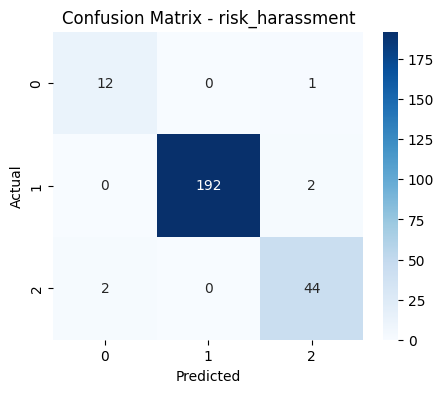

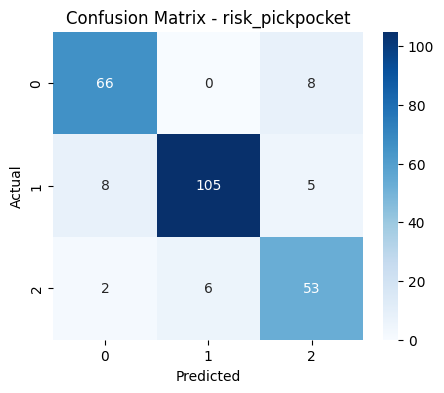

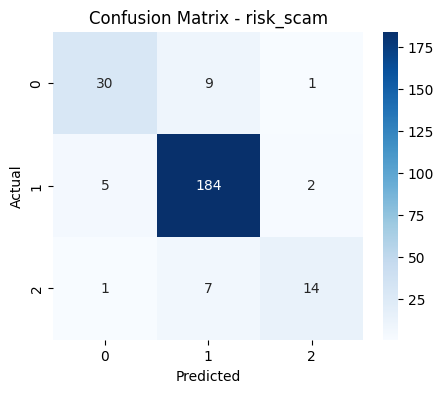

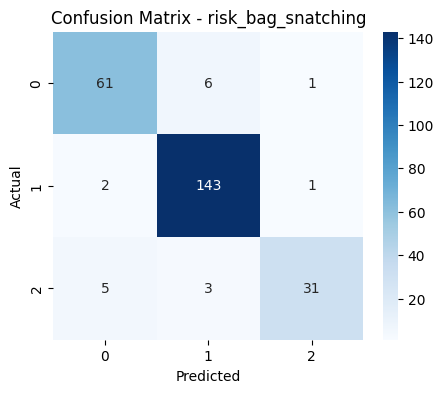

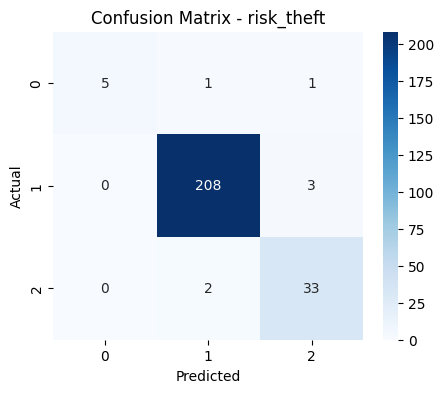

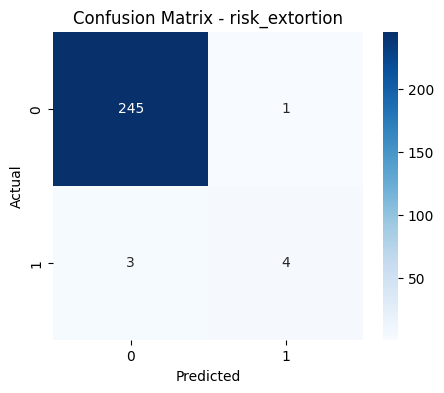

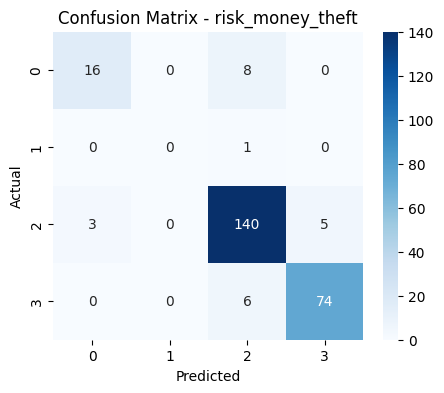

In [14]:
# =========================================
# 8. MODEL EVALUATION METRICS
# =========================================

print("\n============================")
print(" MODEL EVALUATION METRICS")
print("============================\n")

# Convert encoded predictions back to labels
def decode_labels(encoded_df, encoders):
    decoded = pd.DataFrame()
    for col in encoded_df.columns:
        decoded[col] = encoders[col].inverse_transform(encoded_df[col])
    return decoded

# Decode true and predicted labels
y_test_decoded = decode_labels(y_test, target_encoders)
y_pred_rf = decode_labels(pd.DataFrame(rf.predict(X_test), columns=TARGET_COLS), target_encoders)

# Classification Report per incident type
for col in TARGET_COLS:
    print(f"\n===== Classification Report: {col} =====")
    print(classification_report(y_test_decoded[col], y_pred_rf[col]))

# Confusion Matrix for each incident type
for col in TARGET_COLS:
    plt.figure(figsize=(5,4))
    cm = confusion_matrix(y_test_decoded[col], y_pred_rf[col])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {col}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



 RANDOM FOREST FEATURE IMPORTANCE



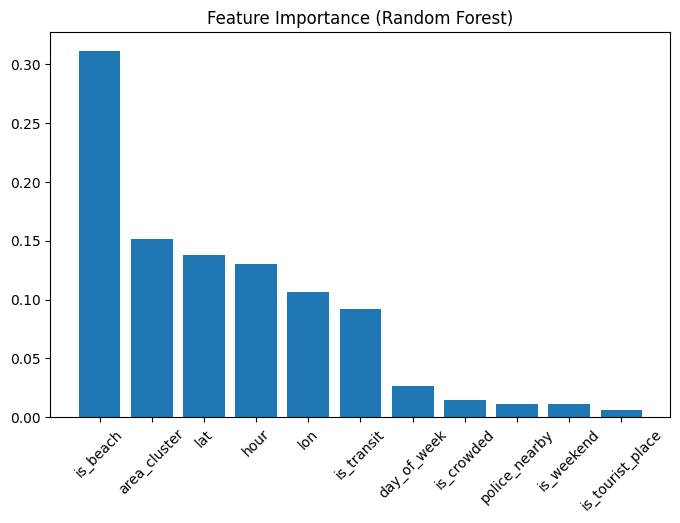

In [16]:
# =========================================
# 10. RANDOM FOREST FEATURE IMPORTANCE
# =========================================

print("\n============================")
print(" RANDOM FOREST FEATURE IMPORTANCE")
print("============================\n")

import numpy as np

# Use one estimator to show importance
importances = rf.estimators_[0].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [FEATURE_COLS[i] for i in indices], rotation=45)
plt.title("Feature Importance (Random Forest)")
plt.show()


In [17]:
print(target_encoders)

{'risk_harassment': LabelEncoder(), 'risk_pickpocket': LabelEncoder(), 'risk_scam': LabelEncoder(), 'risk_bag_snatching': LabelEncoder(), 'risk_theft': LabelEncoder(), 'risk_extortion': LabelEncoder(), 'risk_money_theft': LabelEncoder()}
